In [1]:
import pandas as pd
import pickle
# from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/green_tripdata_2024-11.parquet")

### Explore Data

In [3]:
# TODO: Test more EDA and data cleaning steps here

df[df["Trip_Distance"] > 100].describe()
df[df["Passengers"] < 1].shape

(2256, 14)

### Engineer Features
We need to create new feature to be used in training which is a representation for the actual trip. So the prediction depends also on the trip itself not just the distance. Same distance doesnt mean same duration, hence we need to catch the influence of each trip which is represented by start/stop zone combination.
The real trick here is to recognize that what we need to capture is only which trip is influencing the current prediction. Either trip 1, 2, 3,.....
We need to also avoid capturing the zone codes since they have no meaning neither affect on the duration. If we can encode the relevant trip with "1" while keeping irrelevant ones "0" we capture that a certain trip is the one considered in the equation (others are zero, because each trip/row/training-sample corresponds to a specific trip). These are called categorical in ML terms, as opposed to numerical as the case with trip_distance.

This is actually a technique called one-hot encoding. `DictVectorizer` from scikit-learn can be used for that matter:
1. we create a vector of trips (string combination of start/stop zones StartZone_StopZone)
2. we give the vector to `DictVectorizer` to encode each trip

```
"132_45"  →  [1, 0, 0, ...]
"132_77"  →  [0, 1, 0, ...]
```


In [4]:
df["Trip_Start_dt"] = pd.to_datetime(df["Trip_Start"])
df["Trip_End_dt"] = pd.to_datetime(df["Trip_End"])
df["Trip_Duration"] = (df["Trip_Duration"] / 60).astype("float")
df["PU_DO"] = (df["Start_Zone"].astype("string") + "_" + df["End_Zone"].astype("string"))


In [5]:
df[["Trip_Duration", "PU_DO", "Trip_Distance"]].head().to_dict(orient="records")

[{'Trip_Duration': 40.416666666666664,
  'PU_DO': '97_50',
  'Trip_Distance': 6.679999828338623},
 {'Trip_Duration': 5.483333333333333,
  'PU_DO': '166_41',
  'Trip_Distance': 1.440000057220459},
 {'Trip_Duration': 2.0166666666666666,
  'PU_DO': '129_82',
  'Trip_Distance': 0.20999999344348907},
 {'Trip_Duration': 40.28333333333333,
  'PU_DO': '66_164',
  'Trip_Distance': 6.599999904632568},
 {'Trip_Duration': 6.8, 'PU_DO': '83_83', 'Trip_Distance': 0.9700000286102295}]

### Cleaning Data
Some data are corrupt and unusable. Like unreasonable duration or a duration with negative value. We need to remove them before proceeding

### Preparing Train dict

In [6]:
df = df[(df["Trip_Duration"] >= 1) & (df["Trip_Duration"] <= 60)]
df = df[df["Trip_Distance"] <= 100]
df = df[df["Passengers"] > 0]
X_dict_raw = df[['Trip_Distance'] + ["PU_DO"]].to_dict(orient="records")
vec = DictVectorizer()
X_train = vec.fit_transform(X_dict_raw)
Y_train = df['Trip_Duration'].values

### Training

We are using LinearRegression.


In [7]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_train)

### Visualization
We want to show two things here:
1. Is each prediction close to its own actual? via scatter plot
2. Do predicted durations look like real durations? via kde plot

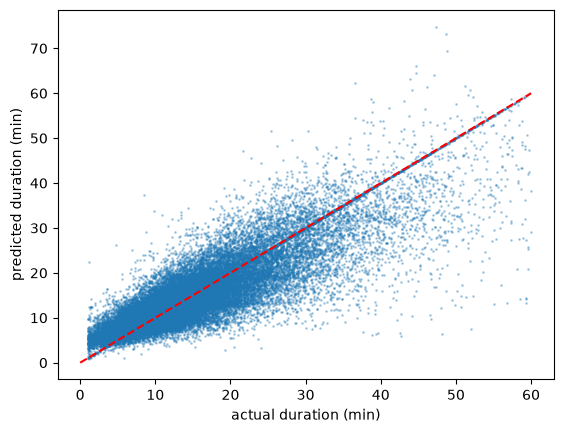

In [8]:
plt.scatter(Y_train, Y_pred, s=1, alpha=0.3)
plt.plot([0, 60], [0, 60], "r--")
plt.xlabel("actual duration (min)")
plt.ylabel("predicted duration (min)")

plt.show()

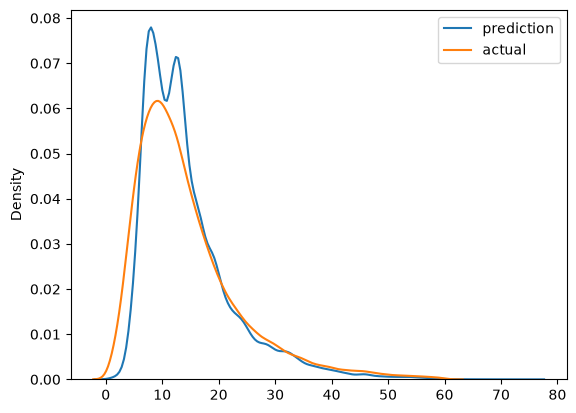

In [9]:
sns.kdeplot(Y_pred, label="prediction", color="tab:blue")
sns.kdeplot(Y_train, label="actual",     color="tab:orange")
plt.legend()


# Evaluation

Calculating the error is simple — for each trip, take the difference between
prediction and actual:

    error = prediction − actual

To evaluate the model's predictive performance (regression talks about *error*,
not *accuracy* — that term belongs to classification):

1. **MAE (Mean Absolute Error)** — how far predictions are from the actual
   values on average. Every error weighs equally; large errors are not amplified.

   MAE = mean( |prediction − actual| )

2. **RMSE (Root Mean Squared Error)** — same idea, but errors are squared before
   averaging, so large errors dominate (outliers amplified); the root returns the
   number to the target's unit (minutes).

   RMSE = sqrt( mean( (prediction − actual)² ) )

A useful **diagnostic** is the ratio RMSE/MAE — it describes the *shape* of the
errors and tells you which problem to hunt:

1. Ratio ≈ 1 → theoretical baseline does not occur
2. Ratio ≈ 1.25 (Normal Distribution) -> consistent (uniform) error sizes → improve the whole model:
   more/better features, more data, a bigger model. Measure progress with MAE.
3. Ratio > 1.5 → inconsistent errors, tailed-distribution, occasional large outliers → hunt the subset:
   which routes/trips/hours fail? (Faulty sensor readings may have corrupted a
   subset of the data — or a feature is missing for that segment.)

Note: consistency describes the error shape, not model quality — a model can be
consistently bad.

Note about the dataset: to measure the metrics truthfully we use a newer dataset from the following month, since the model is created to predict future durations. Anyway we need to make sure the dataset is cleaned likewise.

**Critical**
We need to pass the same `DictVectorizer` object from the training phase but now with `transform` not `fit_transform`. The reason is through it has the encoding for the trips in the November dataset, otherwise re-encoding trips in December's dataset might overwrite or result in conflicting encodings for different trips, which is like changing the language the model trained on. 

e.g.

```
trip in Nov vocabulary  = PU_DO=132_77  → encode trip [0,1,0,...] →  train model and get corresponding weight (w)
trip in Dec vocabulary  = PU_DO=132_77  → encoding already done. Just apply it [0,1,0,...]  →  model applies learned (w) to the same route
```

In [10]:
df_eval = pd.read_parquet("../data/green_tripdata_2024-12.parquet")

In [11]:
df_eval["Trip_Start_dt"] = pd.to_datetime(df_eval["Trip_Start"])
df_eval["Trip_End_dt"] = pd.to_datetime(df_eval["Trip_End"])
df_eval["Trip_Duration"] = (df_eval["Trip_Duration"] / 60 ).astype("float")
df_eval["PU_DO"] = (df_eval["Start_Zone"].astype("string") + "_" + df_eval["End_Zone"].astype("string"))

df_eval = df_eval[(df_eval["Trip_Duration"] >= 1) & (df_eval["Trip_Duration"] <= 60)]
df_eval = df_eval[df_eval["Trip_Distance"] <= 100]
df_eval = df_eval[df_eval["Passengers"] > 0]
X_eval_dict_raw = df_eval[["Trip_Distance"] + ["PU_DO"]].to_dict(orient="records")
X_eval = vec.transform(X_eval_dict_raw)
Y_eval = df_eval['Trip_Duration'].values

In [12]:
Y_eval_pred = lr.predict(X_eval)

In [13]:
rmse = root_mean_squared_error(Y_eval, Y_eval_pred)
mae = mean_absolute_error(Y_eval, Y_eval_pred)
ratio = rmse / mae

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"Ratio: {ratio}")

RMSE: 5.939494980510588
MAE: 3.7998068314264457
Ratio: 1.5631044534653107


### Findings
Let's find out what the results mean:

1. Error Distribution: Naturally the distribution will be around zero, but we can observe from the graph that there is a tendency to be late than to arrive early, hence the tail towards larger positive numbers.
2. CDF (Cumulative Distribution Function): This is a statistical function that helps calculating the ratio of predicted durations which have maximum error of a certain value. This helps answering questions like:
    - What is the percentage of the trips that is late for more than 10 minutes?
    - What is the maximum delay for 95% percent of trips?
    - Questions about percentiles basically

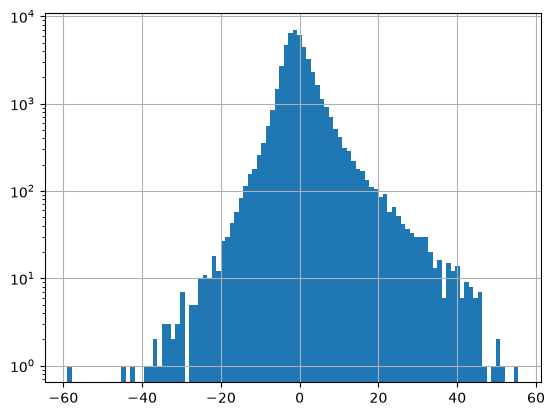

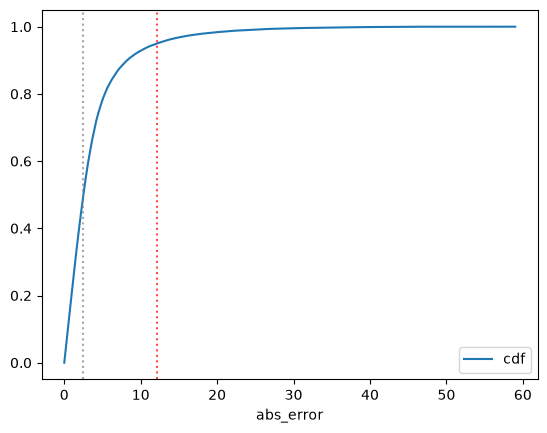

In [14]:
errors = pd.Series(Y_eval - Y_eval_pred, name="error")
errors.hist(bins=100, log=True)


ecdf = pd.DataFrame({"abs_error": errors.abs().sort_values().reset_index(drop=True)})
ecdf["cdf"] = (ecdf.index + 1) / len(ecdf)   # row#/total = accumulated share
ax = ecdf.plot(x="abs_error", y="cdf")
p50 = ecdf[ecdf["cdf"] >= 0.50]["abs_error"].iloc[0]
p95 = ecdf[ecdf["cdf"] >= 0.95]["abs_error"].iloc[0]
ax.axvline(p50, color="gray", linestyle=":", alpha=0.7)
ax.axvline(p95, color="red",  linestyle=":", alpha=0.7)


In [15]:
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | Ratio: {ratio:.2f} | p50: {p50:.1f} | p95: {p95:.1f}")

MAE: 3.80 | RMSE: 5.94 | Ratio: 1.56 | p50: 2.5 | p95: 12.1


# Save the model

In [16]:
with open("../models/baseline.pkl", "wb") as f:
    pickle.dump({"model": lr, "dv": vec}, f)